# Mini-Project 1 — UBOS District Population Forecaster

**Scenario.** A district planning unit needs 5-year population forecasts (2025–2029) to plan primary-school classrooms. We have 10 years (2015–2024) of population estimates in **thousands**.

**Approach.** The domain logic lives in [`src/population.py`](src/population.py); this notebook only *uses* it:

| Class | Responsibility | OOP idea |
|---|---|---|
| `DistrictPopulation` | Validated series, descriptive stats, growth, train/test split | Encapsulation, `__repr__`, `__len__`, `__iter__`, `__getitem__` |
| `Forecaster` (abstract) | Common `fit()` / `predict(horizon)` interface | Abstraction, template method |
| `LinearTrendForecaster`, `ExponentialGrowthForecaster`, `FibonacciRatioForecaster` | The three models | Inheritance, polymorphism |
| `ModelSelector` | Hold-out validation and model choice | Composition (*has* forecasters) |
| `BootstrapPredictionInterval` | Residual-bootstrap 95 % intervals for any model | Polymorphism |
| `ClassroomPlanner` | Population → classrooms | Frozen dataclass with validation |

### Assumptions
1. All data are **illustrative** (from the brief). Mbarara and Arua are my own illustrative additions: Mbarara grows steadily by roughly 15–17 thousand a year; Arua has a 2017–2018 jump that mimics a refugee influx, followed by slow growth — a deliberate stress test for the models.
2. Train on 2015–2021 (7 years), test on 2022–2024 (3 years). The winner is chosen by **RMSE** (it penalises large misses, which matter most for infrastructure), and MAE and MAPE are reported alongside it.
3. After selection, the winning model is **refit on all ten years** before forecasting 2025–2029, so the forecast uses the most recent information.
4. Classrooms: 18 % of the population is of primary-school age and a classroom holds 53 pupils. The 2024 classroom stock is assumed to exactly meet 2024 need, so *additional* classrooms are driven only by growth.

In [2]:
import statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.population import (
    DistrictPopulation, Forecaster, LinearTrendForecaster, ExponentialGrowthForecaster,
    FibonacciRatioForecaster, ModelSelector, BootstrapPredictionInterval,
    ClassroomPlanner, fibonacci,
)

SEED = 2026                       # used for every random operation
rng = np.random.default_rng(SEED) # (the bootstrap takes the same seed)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

YEARS = list(range(2015, 2025))
LAST_TRAIN_YEAR = 2021
HORIZON = 5  # 2025-2029

ModuleNotFoundError: No module named 'numpy'

## Task 1 — `DistrictPopulation` objects (including two extra districts)

In [3]:
raw = {
    "Kampala": [1200, 1250, 1300, 1350, 1420, 1500, 1580, 1650, 1720, 1800],
    "Wakiso":  [ 950, 1000, 1070, 1150, 1220, 1300, 1390, 1480, 1570, 1670],
    "Gulu":    [ 320,  330,  345,  360,  375,  390,  410,  430,  455,  480],
    # --- my additions (illustrative) ---
    "Mbarara": [ 460,  477,  491,  508,  523,  541,  555,  572,  589,  604],
    "Arua":    [ 780,  800,  870,  930,  950,  970,  990, 1010, 1030, 1050],
}
districts = [DistrictPopulation(name, YEARS, pops) for name, pops in raw.items()]
for d in districts:
    print(repr(d), "| len =", len(d))

NameError: name 'DistrictPopulation' is not defined

Validation in action: the constructor refuses bad data instead of silently storing it.

In [3]:
bad_inputs = {
    "unequal lengths": ([2015, 2016, 2017], [100, 110]),
    "negative value":  ([2015, 2016], [100, -3]),
    "empty":           ([], []),
}
for label, (y, p) in bad_inputs.items():
    try:
        DistrictPopulation("Test", y, p)
    except ValueError as err:
        print(f"{label:16s} -> ValueError: {err}")

unequal lengths  -> ValueError: Length mismatch: 3 years but 2 populations.
negative value   -> ValueError: Populations cannot be negative.
empty            -> ValueError: A population series needs at least one observation.


## Task 2 — Descriptive statistics: `statistics` vs NumPy

In [4]:
rows = []
for d in districts:
    s = d.stats_with_statistics()
    n0 = d.stats_with_numpy(ddof=0)
    n1 = d.stats_with_numpy(ddof=1)
    rows.append({
        "District": d.name, "Mean": s["mean"], "Median": s["median"],
        "statistics.variance": s["variance"], "np.var (ddof=0)": n0["variance"],
        "np.var (ddof=1)": n1["variance"],
        "statistics.stdev": s["std"], "np.std (ddof=0)": n0["std"],
    })
desc = pd.DataFrame(rows).set_index("District")
desc

,Mean,Median,statistics.variance,np.var (ddof=0),np.var (ddof=1),statistics.stdev,np.std (ddof=0)
District,,,,,,,
Kampala,"1,477.00","1,460.00","42,601.11","38,341.00","42,601.11",206.40,195.81
Wakiso,"1,280.00","1,260.00","60,066.67","54,060.00","60,066.67",245.09,232.51
Gulu,389.50,382.50,"2,885.83","2,597.25","2,885.83",53.72,50.96
Mbarara,532.00,532.00,"2,354.44","2,119.00","2,354.44",48.52,46.03
Arua,938.00,960.00,"8,751.11","7,876.00","8,751.11",93.55,88.75


In [5]:
# Check: the two variances differ by exactly the factor n/(n-1) = 10/9
ratio = desc["statistics.variance"] / desc["np.var (ddof=0)"]
print("statistics.variance / np.var =", ratio.round(6).unique(), "| n/(n-1) =", 10/9)

statistics.variance / np.var = [1.111111] | n/(n-1) = 1.1111111111111112


**Why the numbers differ.** `statistics.variance` computes the **sample** variance, $s^2=\frac{1}{n-1}\sum (x_i-\bar x)^2$, whereas `np.var` by default computes the **population** variance, $\sigma^2=\frac{1}{n}\sum (x_i-\bar x)^2$. Dividing by $n-1$ (Bessel's correction) compensates for the fact that deviations are measured from the *sample* mean, which is itself fitted to the data and so makes the deviations slightly too small. With $n=10$ the sample variance is exactly $10/9$ of the population variance, as the check above confirms.

**`ddof`** ("delta degrees of freedom") sets the divisor to $n-\text{ddof}$. `ddof=0` → population formula; `ddof=1` → sample formula, identical to `statistics.variance` (column 5 equals column 3). Here the ten years are one realisation of an ongoing process, so `ddof=1` is the more appropriate choice.

A caveat: these series are trending, so their "variance" mostly measures **how far the level travelled over ten years**, not year-to-year volatility. Kampala's variance is large because Kampala grew by 600 thousand, not because it is erratic.

## Task 3 — Year-on-year growth and CAGR

In [6]:
yoy = pd.DataFrame({d.name: d.yoy_growth() * 100 for d in districts}, index=YEARS[1:])
yoy.index.name = "Year"
yoy

,Kampala,Wakiso,Gulu,Mbarara,Arua
Year,,,,,
2016,4.17,5.26,3.12,3.70,2.56
2017,4.00,7.00,4.55,2.94,8.75
2018,3.85,7.48,4.35,3.46,6.90
2019,5.19,6.09,4.17,2.95,2.15
2020,5.63,6.56,4.00,3.44,2.11
2021,5.33,6.92,5.13,2.59,2.06
2022,4.43,6.47,4.88,3.06,2.02
2023,4.24,6.08,5.81,2.97,1.98
2024,4.65,6.37,5.49,2.55,1.94


In [7]:
growth = pd.DataFrame({
    "CAGR 2015-24 (%)": [d.cagr() * 100 for d in districts],
    "Mean YoY (%)":     [yoy[d.name].mean() for d in districts],
    "Std YoY (pp)":     [yoy[d.name].std() for d in districts],
    "Absolute gain (k)": [d.populations[-1] - d.populations[0] for d in districts],
}, index=[d.name for d in districts]).sort_values("CAGR 2015-24 (%)", ascending=False)

# Second-method check: CAGR equals the geometric mean of (1 + YoY) minus 1
for d in districts:
    geo = statistics.geometric_mean((1 + d.yoy_growth()).tolist()) - 1
    assert np.isclose(geo, d.cagr())
print("CAGR verified against the geometric mean of YoY growth for all districts.")
growth

CAGR verified against the geometric mean of YoY growth for all districts.


,CAGR 2015-24 (%),Mean YoY (%),Std YoY (pp),Absolute gain (k)
Wakiso,6.47,6.47,0.64,720.00
Kampala,4.61,4.61,0.63,600.00
Gulu,4.61,4.61,0.82,160.00
Arua,3.36,3.39,2.56,270.00
Mbarara,3.07,3.07,0.39,144.00


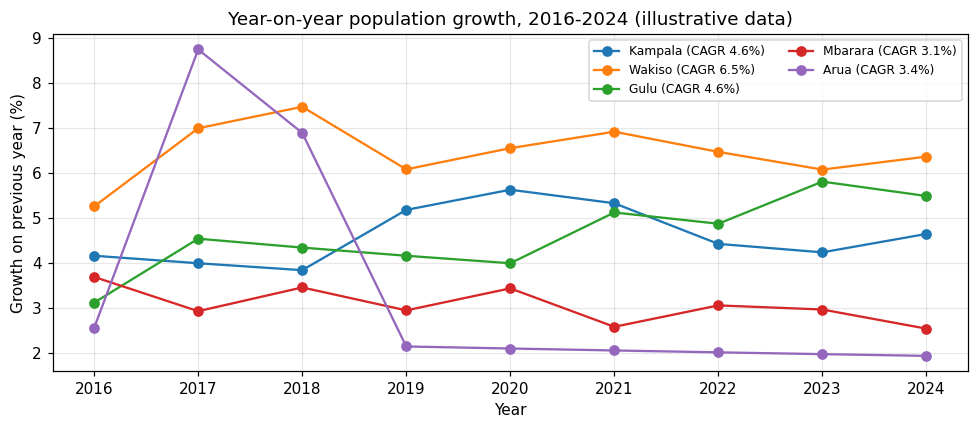

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
for d in districts:
    ax.plot(YEARS[1:], d.yoy_growth() * 100, marker="o", label=f"{d.name} (CAGR {d.cagr():.1%})")
ax.set(title="Year-on-year population growth, 2016-2024 (illustrative data)",
       xlabel="Year", ylabel="Growth on previous year (%)")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout(); fig.savefig("figures/p1_yoy_growth.png", bbox_inches="tight")
plt.show()

**Wakiso is growing fastest in relative terms** (CAGR ≈ 6.5 % a year), and it also added the most people in absolute terms (+720 k) — consistent with its role as Kampala's overflow district. Kampala and Gulu have *identical* CAGRs (≈ 4.6 %) because both grew by a factor of exactly 1.5; this shows that CAGR depends only on the end points and says nothing about the path in between. Arua shows why that matters: its CAGR of 3.4 % averages a 2017–18 surge (≈ 7–9 %) with ≈ 2 % growth since, so the CAGR *overstates* its current momentum.

## Task 4 — Three forecasters behind one abstract interface

In [9]:
candidates = [LinearTrendForecaster(), ExponentialGrowthForecaster(), FibonacciRatioForecaster(start_index=1)]
for m in candidates:
    print(f"{m.label:20s} {m!r:40s} subclass of Forecaster: {isinstance(m, Forecaster)}")

# Polymorphism: identical calls, different behaviour
kampala = districts[0]
for m in candidates:
    print(f"{m.label:20s} next 3 years:", np.round(m.fit_predict(kampala, 3), 1))

Linear trend         LinearTrendForecaster(unfitted)          subclass of Forecaster: True
Exponential (CAGR)   ExponentialGrowthForecaster(unfitted)    subclass of Forecaster: True
Fibonacci ratio      FibonacciRatioForecaster(unfitted)       subclass of Forecaster: True
Linear trend         next 3 years: [1850.7 1918.6 1986.5]
Exponential (CAGR)   next 3 years: [1882.9 1969.7 2060.5]
Fibonacci ratio      next 3 years: [1800. 3600. 5400.]


Each subclass only implements `_fit`, `_predict` and `_fitted`; input checks, the "fit before predict" guard and residuals are inherited from `Forecaster`. So `ModelSelector` and the bootstrap never need to know *which* model they hold.

The Fibonacci model reproduces last cohort's rule: the forecast for year *k* ahead is the last value times the product of successive ratios $F_{i+1}/F_i$ = 1, 2, 1.5, 1.67, … → φ ≈ 1.618. Its output above (1,800 → 1,800 → 3,600 → 5,400) already hints at the problem, which the validation step now quantifies.

Second-method check for the linear model: `np.polyfit` should agree with `scipy.stats.linregress`.

In [10]:
lin = LinearTrendForecaster().fit(kampala.years, kampala.populations)
lr = stats.linregress(kampala.years, kampala.populations)
print(f"polyfit slope = {lin.slope_:.4f} k/yr | linregress slope = {lr.slope:.4f} k/yr")
assert np.isclose(lin.slope_, lr.slope)

polyfit slope = 67.9394 k/yr | linregress slope = 67.9394 k/yr


## Task 5 — Validate before forecasting (train 2015–2021, test 2022–2024)

In [11]:
selector = ModelSelector(candidates, criterion="RMSE")
validation, best_model = {}, {}
for d in districts:
    results = selector.validate(d, LAST_TRAIN_YEAR)
    validation[d.name] = results
    best_model[d.name] = selector.best(results).model
    table = pd.DataFrame({r.model: r.scores for r in results}).T
    table["Selected"] = ["✔" if r.model == best_model[d.name] else "" for r in results]
    print(f"\n=== {d.name} (errors in thousands; MAPE in %) ===")
    display(table)


=== Kampala (errors in thousands; MAPE in %) ===


,MAE,RMSE,MAPE (%),Selected
Linear trend,37.62,38.97,2.17,
Exponential (CAGR),9.62,10.39,0.55,✔
Fibonacci ratio,"1,483.33","1,890.51",83.77,



=== Wakiso (errors in thousands; MAPE in %) ===


,MAE,RMSE,MAPE (%),Selected
Linear trend,49.40,52.37,3.09,
Exponential (CAGR),6.80,8.05,0.42,✔
Fibonacci ratio,"1,266.67","1,604.39",77.62,



=== Gulu (errors in thousands; MAPE in %) ===


,MAE,RMSE,MAPE (%),Selected
Linear trend,18.57,20.29,4.01,
Exponential (CAGR),9.44,10.87,2.02,✔
Fibonacci ratio,378.33,481.71,80.37,



=== Mbarara (errors in thousands; MAPE in %) ===


,MAE,RMSE,MAPE (%),Selected
Linear trend,1.01,1.12,0.17,✔
Exponential (CAGR),2.70,3.44,0.45,
Fibonacci ratio,533.00,682.51,89.03,



=== Arua (errors in thousands; MAPE in %) ===


,MAE,RMSE,MAPE (%),Selected
Linear trend,56.07,57.86,5.42,
Exponential (CAGR),42.45,46.29,4.09,✔
Fibonacci ratio,963.33,"1,236.84",92.36,


In [12]:
summary = pd.DataFrame({
    name: {r.model: r.scores["MAPE (%)"] for r in res} for name, res in validation.items()
}).T
summary["Selected model"] = pd.Series(best_model)
summary.index.name = "District — test MAPE (%)"
summary

,Linear trend,Exponential (CAGR),Fibonacci ratio,Selected model
District — test MAPE (%),,,,
Kampala,2.17,0.55,83.77,Exponential (CAGR)
Wakiso,3.09,0.42,77.62,Exponential (CAGR)
Gulu,4.01,2.02,80.37,Exponential (CAGR)
Mbarara,0.17,0.45,89.03,Linear trend
Arua,5.42,4.09,92.36,Exponential (CAGR)


**Reading the tables.**
* **Exponential (CAGR)** wins for Kampala, Wakiso and Gulu, whose year-on-year growth rates are roughly stable or rising. When the *percentage* growth is constant, the absolute increments grow, and a straight line systematically under-forecasts (the linear model misses Kampala and Wakiso by 2–3 %).
* **Linear trend** wins for Mbarara, which adds a near-constant ~16 k a year; its percentage growth is therefore *falling*, and constant-percentage growth over-forecasts.
* **Arua** is the hard case: both reasonable models over-forecast (MAPE 4–5 %) because the training window contains the 2017–18 surge, which inflates both the slope and the CAGR. The exponential model wins only as the lesser evil.
* **Fibonacci ratio** is off by 78–92 % everywhere — two orders of magnitude worse than the alternatives.

With only 3 test points, the differences between the two sensible models are indicative rather than statistically decisive.

## Task 6 — Forecast 2025–2029 with the selected model (+ bootstrap 95 % intervals)

In [13]:
boot = BootstrapPredictionInterval(n_resamples=1000, alpha=0.05, seed=SEED)
future_years = np.arange(YEARS[-1] + 1, YEARS[-1] + 1 + HORIZON)
forecasts = {}
for d in districts:
    model = selector.prototype(best_model[d.name])        # fresh, unfitted copy
    forecasts[d.name] = boot.run(model, d, HORIZON)        # refit on all 10 years

fc_table = pd.concat({
    name: pd.DataFrame({"Forecast": pi.point, "Lower 95%": pi.lower, "Upper 95%": pi.upper},
                       index=future_years)
    for name, pi in forecasts.items()
}, axis=1)
fc_table.index.name = "Year"
fc_table.round(1)

Kampala                       Wakiso                         Gulu  \
     Forecast Lower 95% Upper 95% Forecast Lower 95% Upper 95% Forecast   
Year                                                                      
2025 1,882.90  1,852.60  1,906.90 1,778.00  1,758.60  1,792.30   502.10   
2026 1,969.70  1,934.90  1,996.00 1,893.00  1,872.50  1,908.40   525.30   
2027 2,060.50  2,022.90  2,090.30 2,015.50  1,992.90  2,032.80   549.50   
2028 2,155.40  2,114.10  2,189.70 2,145.90  2,120.00  2,167.50   574.80   
2029 2,254.80  2,206.70  2,296.90 2,284.70  2,253.60  2,308.90   601.30   

                          Mbarara                         Arua            \
     Lower 95% Upper 95% Forecast Lower 95% Upper 95% Forecast Lower 95%   
Year                                                                       
2025    493.00    514.10   620.10    618.50    621.70 1,085.30  1,014.60   
2026    515.10    538.40   636.20    634.40    638.00 1,121.70  1,045.80   
2027    537.90    563.60   652.20    650.30    654.10 1,159.40  1,073.70   
2028    561.60    590.80   668.20    666.10    670.40 1,198.30  1,102.30   
2029    586.10    618.80   684.20    682.10    686.40 1,238.50  1,134.70   

                
     Upper 95%  
Year            
2025  1,156.90  
2026  1,202.20  
2027  1,245.30  
2028  1,296.00  
2029  1,354.10

In [14]:
var_rows = []
for d in districts:
    fc = forecasts[d.name].point
    var_rows.append({
        "District": d.name,
        "Var actual 2015-24": np.var(d.populations, ddof=1),
        "Var actual 2020-24 (5 yrs)": np.var(d.populations[-5:], ddof=1),
        "Var forecast 2025-29": np.var(fc, ddof=1),
        "Var of annual change, actual": np.var(np.diff(d.populations), ddof=1),
        "Var of annual change, forecast": np.var(np.diff(fc), ddof=1),
    })
pd.DataFrame(var_rows).set_index("District")

,Var actual 2015-24,Var actual 2020-24 (5 yrs),Var forecast 2025-29,"Var of annual change, actual","Var of annual change, forecast"
District,,,,,
Kampala,"42,601.11","13,700.00","21,607.68",175.00,29.21
Wakiso,"60,066.67","21,170.00","40,131.36",225.00,104.90
Gulu,"2,885.83","1,270.00","1,536.55",25.69,2.08
Mbarara,"2,354.44",640.70,641.94,2.25,0.00
Arua,"8,751.11","1,000.00","3,671.53",400.00,2.67


**What the variance comparison says.** The forecast variance is *smaller* than the variance of the ten actual years, but that is mostly an artefact of **window length**: for a trending series, the variance of the levels grows with the span covered. A fairer comparison is with the last five actual years — against that, the forecast variance is actually *larger* for the four exponential districts, because constant-percentage growth produces ever-bigger absolute increments, and it is virtually identical for Mbarara's linear forecast (642 vs 641). Arua stands out: its forecast variance is more than three times that of its last five actual years, a sign that the model is extrapolating the old surge rather than the recent slowdown.

The more revealing columns are the last two. The actual **annual changes** vary (for Arua, dramatically), whereas the forecast's annual changes are almost perfectly regular (exactly zero variance for the linear model). The forecast is a *smooth expectation*: it contains the trend but none of the year-to-year shocks that real data have. Low forecast variance therefore must **not** be read as low uncertainty — the uncertainty has to be represented separately, which is what the bootstrap intervals do.

## Task 7 — Actual, fitted and forecast values for every district

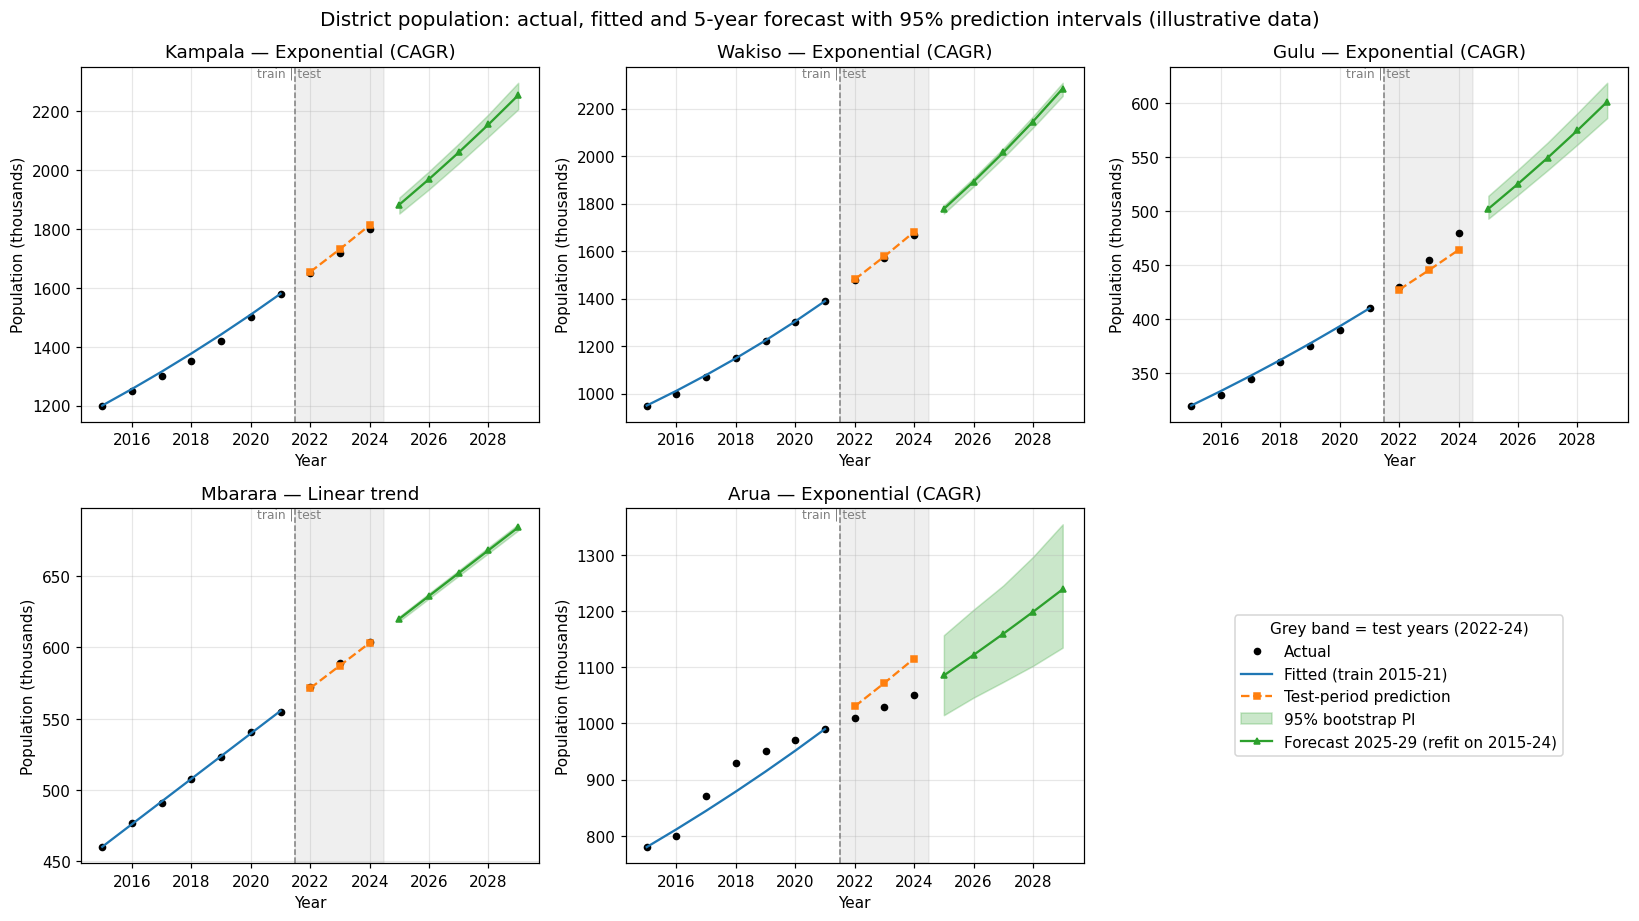

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
split_x = LAST_TRAIN_YEAR + 0.5
for ax, d in zip(axes.flat, districts):
    train, test = d.split(LAST_TRAIN_YEAR)
    label = best_model[d.name]
    val_model = selector.prototype(label).fit(train.years, train.populations)
    pi = forecasts[d.name]

    ax.axvspan(split_x, YEARS[-1] + 0.5, color="grey", alpha=0.12)
    ax.axvline(split_x, color="grey", ls="--", lw=1)
    ax.plot(d.years, d.populations, "ko", ms=4, label="Actual")
    ax.plot(train.years, val_model.fitted_values(), "C0-", label="Fitted (train 2015-21)")
    ax.plot(test.years, val_model.predict(len(test)), "C1s--", ms=4, label="Test-period prediction")
    ax.fill_between(future_years, pi.lower, pi.upper, color="C2", alpha=0.25, label="95% bootstrap PI")
    ax.plot(future_years, pi.point, "C2^-", ms=4, label="Forecast 2025-29 (refit on 2015-24)")
    ax.set_title(f"{d.name} — {label}")
    ax.set_xlabel("Year"); ax.set_ylabel("Population (thousands)")
    ax.text(split_x - 0.2, ax.get_ylim()[1], "train | test", ha="center", va="top", fontsize=8, color="grey")

legend_ax = axes.flat[-1]
legend_ax.axis("off")
legend_ax.legend(*axes.flat[0].get_legend_handles_labels(), loc="center", fontsize=10,
                 title="Grey band = test years (2022-24)")
fig.suptitle("District population: actual, fitted and 5-year forecast with 95% prediction intervals "
             "(illustrative data)", fontsize=13)
fig.tight_layout(); fig.savefig("figures/p1_forecasts.png", bbox_inches="tight")
plt.show()

The panels support two points made above. For Kampala, Wakiso and Gulu the test-period predictions (orange squares) sit on or close to the actuals (Gulu drifts slightly low because its growth accelerated after 2021), and the intervals are narrow. For **Arua** the orange squares lie visibly above the actuals, and its 2029 bootstrap interval (≈ 220 k wide) is about fifty times wider than Mbarara's (≈ 4 k), because the in-sample residuals include the surge. The model's uncertainty is therefore honest, even though its central path is too high.

## Task 8 — Planning output: additional classrooms needed by 2029

In [16]:
planner = ClassroomPlanner(school_age_share=0.18, pupils_per_classroom=53)
plan_rows = []
for d in districts:
    pi = forecasts[d.name]
    now = d.populations[-1]
    plan_rows.append({
        "District": d.name,
        "Model": best_model[d.name],
        "Pop 2024 (k)": now,
        "Pop 2029 (k)": pi.point[-1],
        "Extra pupils": planner.pupils(pi.point[-1]) - planner.pupils(now),
        "Extra classrooms": planner.additional_classrooms(now, pi.point[-1]),
        "Low (2.5%)": planner.additional_classrooms(now, pi.lower[-1]),
        "High (97.5%)": planner.additional_classrooms(now, pi.upper[-1]),
        "Per year": planner.additional_classrooms(now, pi.point[-1]) / HORIZON,
    })
plan = pd.DataFrame(plan_rows).set_index("District")
plan.loc["Total", ["Extra pupils", "Extra classrooms", "Low (2.5%)", "High (97.5%)", "Per year"]] = \
    plan[["Extra pupils", "Extra classrooms", "Low (2.5%)", "High (97.5%)", "Per year"]].sum()
plan

,Model,Pop 2024 (k),Pop 2029 (k),Extra pupils,Extra classrooms,Low (2.5%),High (97.5%),Per year
District,,,,,,,,
Kampala,Exponential (CAGR),"1,800.00","2,254.76","81,857.42","1,544.00","1,381.00","1,687.00",308.80
Wakiso,Exponential (CAGR),"1,670.00","2,284.67","110,640.73","2,088.00","1,982.00","2,170.00",417.60
Gulu,Exponential (CAGR),480.00,601.27,"21,828.64",412.00,360.00,471.00,82.40
Mbarara,Linear trend,604.00,684.23,"14,441.45",272.00,265.00,280.00,54.40
Arua,Exponential (CAGR),"1,050.00","1,238.54","33,936.45",640.00,287.00,"1,032.00",128.00
Total,NaN,NaN,NaN,"262,704.70","4,956.00","4,275.00","5,640.00",991.20


Kampala by hand: ceil(2254.8k x 1000 x 0.18 / 53) - ceil(1800k x 1000 x 0.18 / 53) = 1544


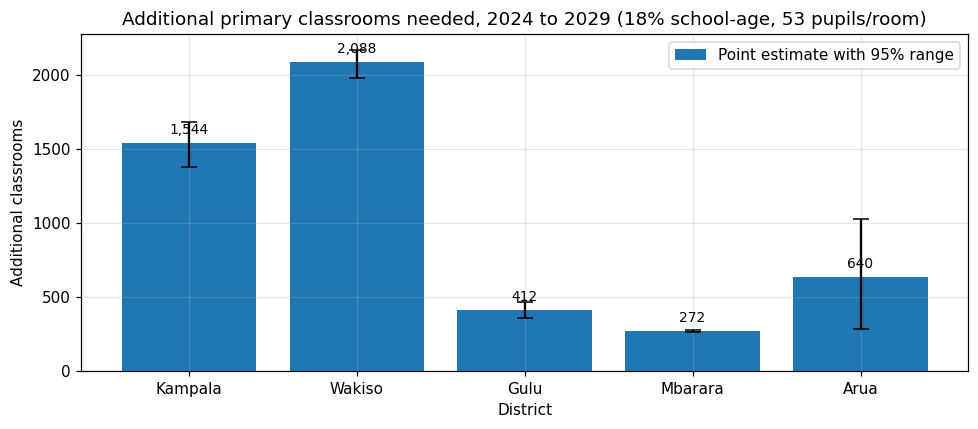

In [17]:
# Hand calculation for Kampala, to check the planner
k = plan.loc["Kampala"]
hand = int(np.ceil(k["Pop 2029 (k)"] * 1000 * 0.18 / 53)) - int(np.ceil(1800 * 1000 * 0.18 / 53))
print(f"Kampala by hand: ceil({k['Pop 2029 (k)']:.1f}k x 1000 x 0.18 / 53) - ceil(1800k x 1000 x 0.18 / 53) = {hand}")
assert hand == k["Extra classrooms"]

p = plan.drop(index="Total")
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(p.index, p["Extra classrooms"], color="C0",
       yerr=[p["Extra classrooms"] - p["Low (2.5%)"], p["High (97.5%)"] - p["Extra classrooms"]],
       capsize=5, label="Point estimate with 95% range")
for i, v in enumerate(p["Extra classrooms"]):
    ax.text(i, v + 60, f"{v:,.0f}", ha="center", fontsize=9)
ax.set(title="Additional primary classrooms needed, 2024 to 2029 (18% school-age, 53 pupils/room)",
       xlabel="District", ylabel="Additional classrooms")
ax.legend(); fig.tight_layout(); fig.savefig("figures/p1_classrooms.png", bbox_inches="tight")
plt.show()

Wakiso needs the most new classrooms (≈ 2,100, i.e. roughly 420 a year), which is more than Kampala even though Kampala is the larger district. Growth, not size, drives new construction. Arua's range is the widest in relative terms, so a planner there should phase construction and re-forecast annually rather than commit to the point estimate.

## Extension A — Bootstrap prediction intervals

The intervals above come from `BootstrapPredictionInterval` with **1,000 resamples** (seed 2026). For each resample, the in-sample residuals of the selected model are shuffled with replacement and added back to the fitted values to create a pseudo-history. The model is **refit** on this pseudo-history (parameter uncertainty), and freshly resampled residuals are added to its forecast (future noise). The 2.5th and 97.5th percentiles give the 95 % interval.

Interval widths in 2029:

In [18]:
widths = pd.DataFrame({
    "2029 forecast (k)": [forecasts[n].point[-1] for n in raw],
    "PI width 2029 (k)": [forecasts[n].width()[-1] for n in raw],
}, index=list(raw))
widths["Width as % of forecast"] = 100 * widths["PI width 2029 (k)"] / widths["2029 forecast (k)"]
widths

,2029 forecast (k),PI width 2029 (k),Width as % of forecast
Kampala,"2,254.76",90.19,4.00
Wakiso,"2,284.67",55.32,2.42
Gulu,601.27,32.65,5.43
Mbarara,684.23,4.29,0.63
Arua,"1,238.54",219.36,17.71


**Limits of this bootstrap.** With only ten residuals, the resampling can generate only combinations of the few shocks already seen. The intervals assume residuals are independent and identically distributed, and they carry no *structural* uncertainty (a new census base, a policy change, a new refugee wave). They should be read as a **lower bound** on the true uncertainty.

## Extension B — Is the Fibonacci-ratio model ever defensible?

In [19]:
fib_model = FibonacciRatioForecaster(start_index=1)
ratios = fib_model.ratios(12)
implied = pd.DataFrame({"Ratio F(i+1)/F(i)": ratios, "Implied growth (%)": (ratios - 1) * 100},
                       index=pd.Index(range(1, 13), name="Step i"))
print("Observed CAGRs:", {d.name: f"{d.cagr():.1%}" for d in districts})
implied.T

Observed CAGRs: {'Kampala': '4.6%', 'Wakiso': '6.5%', 'Gulu': '4.6%', 'Mbarara': '3.1%', 'Arua': '3.4%'}


Step i,1,2,3,4,5,6,7,8,9,10,11,12
Ratio F(i+1)/F(i),1.00,2.00,1.50,1.67,1.60,1.62,1.62,1.62,1.62,1.62,1.62,1.62
Implied growth (%),0.00,100.00,50.00,66.67,60.00,62.50,61.54,61.90,61.76,61.82,61.80,61.81


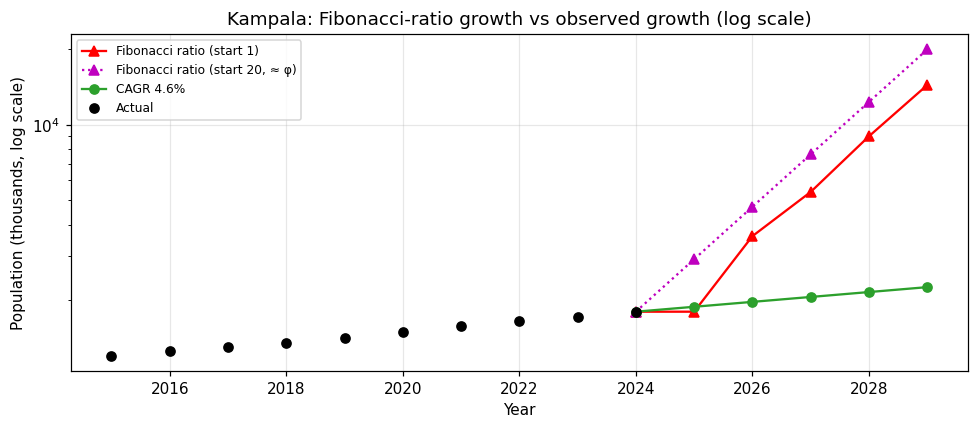

Fibonacci (start 20) forecast for Kampala in 2029: 19,962k (about 40% of Uganda's ~50 million people)


In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
steps = np.arange(0, 6)
last = kampala.populations[-1]
ax.plot(2024 + steps, last * np.r_[1, np.cumprod(fib_model.ratios(5))], "r^-", label="Fibonacci ratio (start 1)")
ax.plot(2024 + steps, last * np.r_[1, np.cumprod(FibonacciRatioForecaster(20).ratios(5))], "m^:",
        label="Fibonacci ratio (start 20, ≈ φ)")
ax.plot(2024 + steps, last * (1 + kampala.cagr()) ** steps, "C2o-", label=f"CAGR {kampala.cagr():.1%}")
ax.plot(kampala.years, kampala.populations, "ko", label="Actual")
ax.set_yscale("log")
ax.set(title="Kampala: Fibonacci-ratio growth vs observed growth (log scale)",
       xlabel="Year", ylabel="Population (thousands, log scale)")
ax.legend(fontsize=8); fig.tight_layout(); fig.savefig("figures/p1_fibonacci_critique.png", bbox_inches="tight")
plt.show()
print(f"Fibonacci (start 20) forecast for Kampala in 2029: {last * np.prod(FibonacciRatioForecaster(20).ratios(5)):,.0f}k "
      f"(about {last * np.prod(FibonacciRatioForecaster(20).ratios(5)) / 1000 / 50:.0%} of Uganda's ~50 million people)")

**Assessment.** The Fibonacci ratios settle at φ ≈ 1.618, i.e. **61.8 % growth per year, whatever the data say**. The early ratios (1, 2, 1.5, …) are not smaller growth rates; they simply oscillate wildly. The model has *no parameter estimated from the data*: `fit()` only stores the last value, so it cannot learn that Kampala grows at 4.6 % and Mbarara at 3.1 %. Starting deep in the sequence (≈ φ) gives Kampala about 20 million people by 2029, around 40 % of the whole country.

It is defensible only when the population genuinely follows $N_t = N_{t-1} + N_{t-2}$: each unit reproduces once per period after a one-period maturation lag, nothing dies, nothing migrates and resources are unlimited. This is Fibonacci's idealised rabbit colony, and at best an early-phase approximation for a *newly founded* population. None of these conditions describes a human district, where fertility, mortality and migration produce low single-digit growth.

The only way to "rescue" it is to replace φ with a ratio estimated from the district's own data, but that turns it into the CAGR model. Its only real use here is as a cautionary baseline.

## Findings & Limitations

**Findings.** Relative growth, not size, drives classroom demand. Wakiso has the highest CAGR (≈ 6.5 %) and needs the most new classrooms by 2029 (≈ 2,100) — more than Kampala (≈ 1,550), despite Kampala's larger population. Across the five districts the selected models imply roughly **5,000 additional classrooms by 2029**, about 1,000 a year. Hold-out validation mattered. Constant-percentage (CAGR) growth beat a straight line wherever year-on-year growth rates were stable or rising (Kampala, Wakiso, Gulu), whereas a linear trend won for Mbarara, whose absolute increments are constant. No single model is "best" everywhere, which justifies choosing a model per district. The Fibonacci-ratio model failed with 78–92 % MAPE because it imposes ~62 % annual growth and learns nothing from the data.

**Interpretation of uncertainty.** A smooth forecast has low variance, but that reflects the absence of simulated shocks, not certainty. The bootstrap intervals make this explicit: for Arua, whose history contains an influx shock, the 2029 interval spans about 18 % of the forecast, against under 1 % for Mbarara. Planners there should phase construction and re-forecast annually.

**Limitations.** The data are illustrative, and ten points is a very short record. The three-year test set cannot separate two good models with statistical confidence. Both surviving models extrapolate past trends and cannot anticipate structural breaks such as refugee arrivals, boundary changes or census rebasing, which is exactly where Arua's forecast goes wrong. The planning rule is deliberately simple: a fixed 18 % school-age share ignores the fertility decline that is gradually shrinking Uganda's child share, it assumes today's classroom stock exactly meets today's need (ignoring existing overcrowding), and it treats all school-age children as enrolled. The bootstrap assumes independent residuals from only ten observations, so the intervals understate true uncertainty.